In [1]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# Load the dataset and convert it to a pandas DataFrame
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean the date and time columns
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_posted_date'] = df['job_posted_date'].dt.tz_localize('UTC')
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else [skill_list])

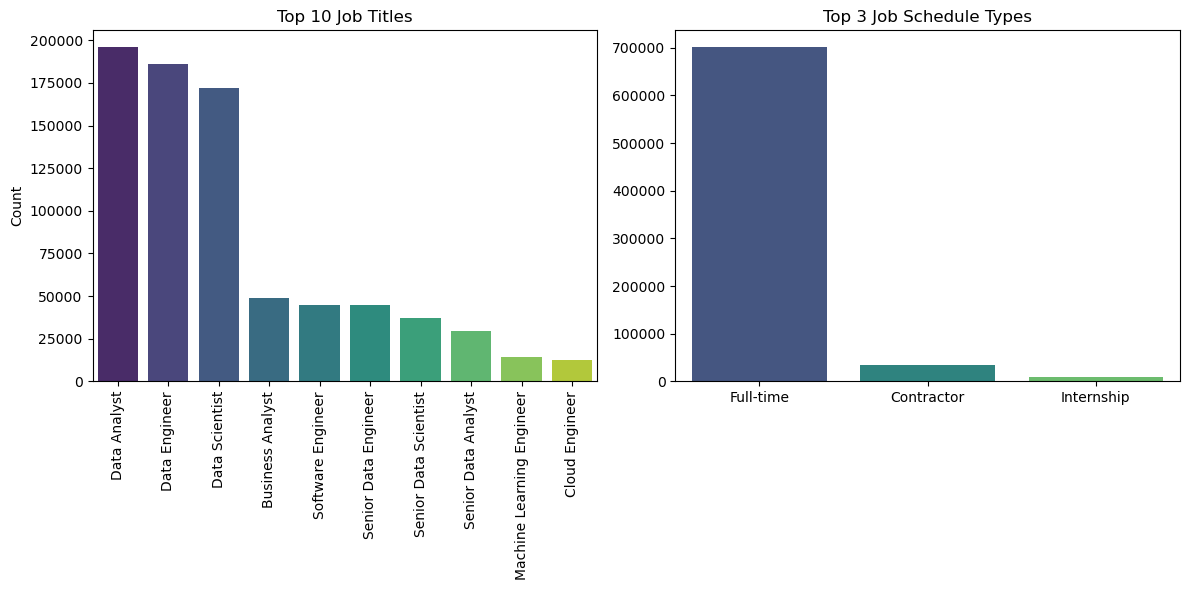

In [2]:
# Analyze the distribution of job types
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plotting the top 10 job titles and top 3 job schedule types
sns.barplot(x=df['job_title_short'].value_counts().head(10).index, 
            y=df['job_title_short'].value_counts().head(10).values, 
            ax=ax[0], 
            hue=df['job_title_short'].value_counts().head(10).index,
            palette='viridis')
ax[0].set_title('Top 10 Job Titles')
ax[0].set_xlabel('')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=90)

# Plotting the top 3 job schedule types
sns.barplot(x=df['job_schedule_type'].value_counts().head(3).index, 
            y=df['job_schedule_type'].value_counts().head(3).values, 
            ax=ax[1], 
            hue=df['job_schedule_type'].value_counts().head(3).index,
            palette='viridis')
ax[1].set_title('Top 3 Job Schedule Types')
ax[1].set_xlabel('')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [3]:
# Filtering for Data Analyst jobs in India, as they are the most common job in India

df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

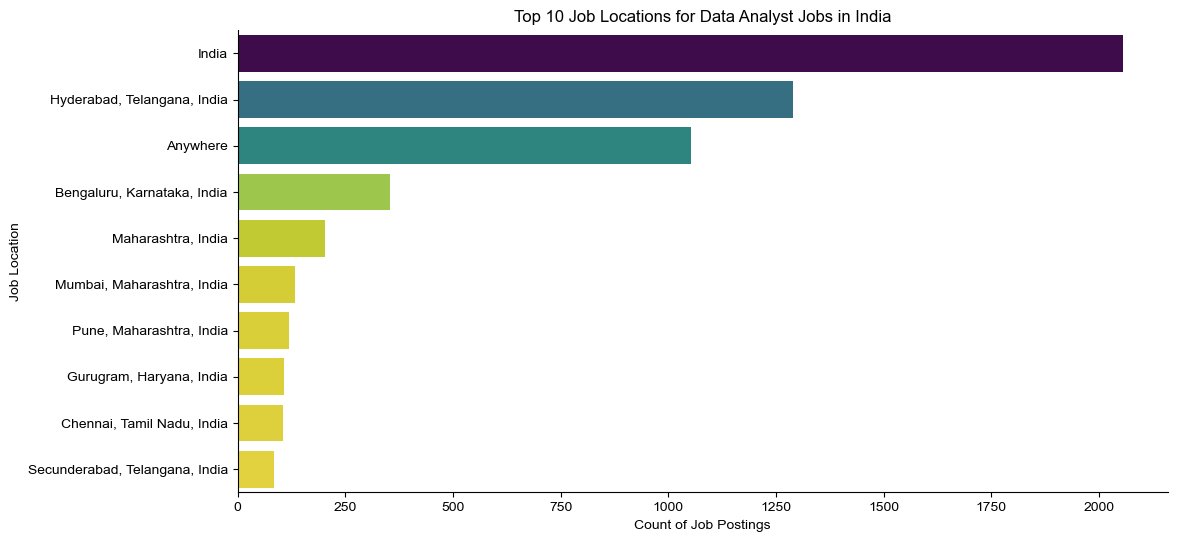

In [4]:
# Displaying the count of job locations for Data Analyst jobs in India
df_locations = df_DA_India['job_location'].value_counts().head(10).to_frame()

# Plotting the distribution of job locations for Data Analyst jobs in India
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_locations, x='count', y='job_location', hue='count', palette='viridis_r', legend=False, ax=ax)
sns.set_theme(style="ticks")
sns.despine()
plt.title('Top 10 Job Locations for Data Analyst Jobs in India')
plt.xlabel('Count of Job Postings')
plt.ylabel('Job Location')
plt.show()

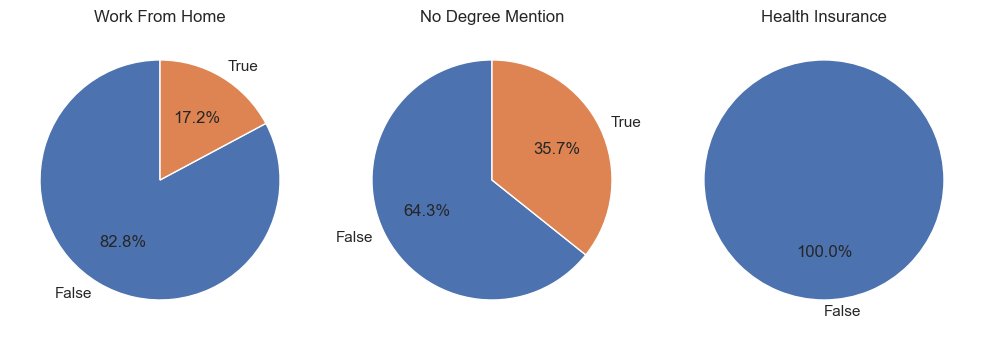

In [5]:
# Analyzing the distribution of work from home, degree mention, and health insurance for Data Analyst jobs in India
fig, ax = plt.subplots(1, 3,figsize=(10, 6))

dict_coulumn = {
    'job_work_from_home': 'Work From Home',
    'job_no_degree_mention': 'No Degree Mention',
    'job_health_insurance': 'Health Insurance'
}

for i, (column, title) in enumerate(dict_coulumn.items()):
    ax[i].pie(df_DA_India[column].value_counts(), labels=df_DA_India[column].value_counts().index, autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.tight_layout()
plt.show()

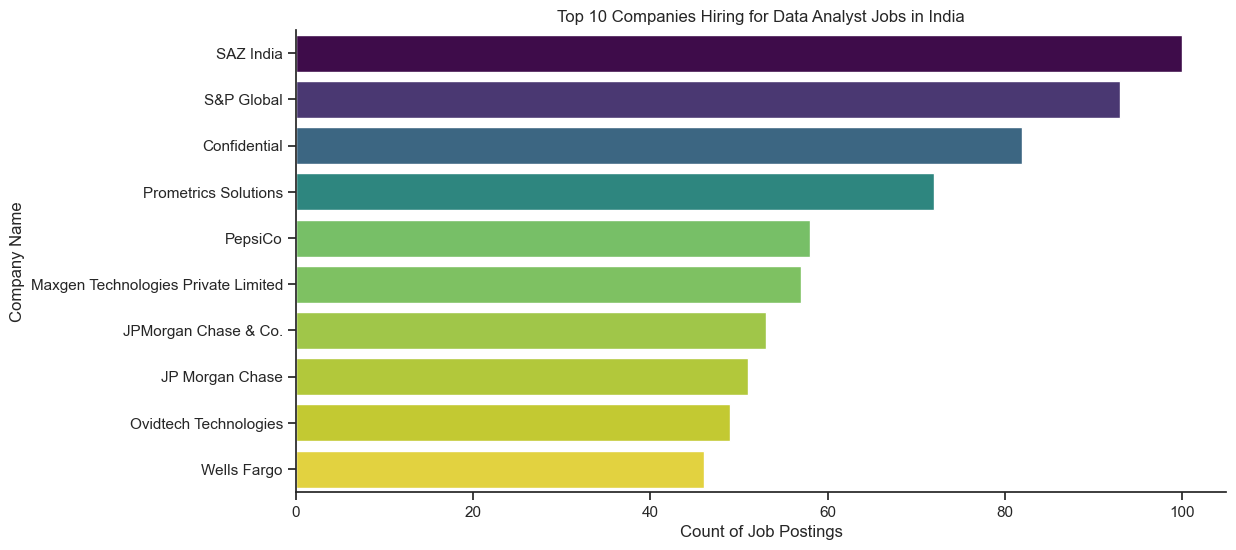

In [6]:
# Displaying the count of companies hiring for Data Analyst jobs in India
df_companies = df_DA_India['company_name'].value_counts().head(10).to_frame()

# Plotting the distribution of companies hiring for Data Analyst jobs in India
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_companies, x='count', y='company_name', hue='count', palette='viridis_r', legend=False, ax=ax)
sns.set_theme(style="ticks")
sns.despine()
plt.title('Top 10 Companies Hiring for Data Analyst Jobs in India')
plt.xlabel('Count of Job Postings')
plt.ylabel('Company Name')
plt.show()